### A PROJECT BY TATENDA USAI

## This project involves identifying which leads are more likely to convert to paid customers based on attributes of leads and their interaction details.

### Decision Trees | Random Forests | Hyperparameter Tuning

# Classification and Hypothesis Testing: Predicting Potential Customers

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For python to display graphs inline
%matplotlib inline


# For decision tree model
from sklearn.tree import DecisionTreeClassifier

# For svm model
from sklearn.svm import SVC

# For logistic regression model
from sklearn.linear_model import LogisticRegression

# Random forest
from sklearn.ensemble import RandomForestClassifier

# Bagging
from sklearn.ensemble import BaggingClassifier

# Metrics used to evaluate the model
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve,recall_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import tree

# For data preprocessing and scaling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# For tuning the machine learning model
from sklearn.model_selection import GridSearchCV

# Used to ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Data Overview

- Observations
- Sanity checks

In [3]:
# To mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# read the data
df = pd.read_csv("/content/drive/MyDrive/DATA SCIENCE AND MACHINE LEARNING/Classification and Hypothesis Testing/ExtraaLearn.csv")

# return first 5 rows
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [5]:
# Checking the data shape
print("We have", df.shape[0], "rows and", df.shape[1], "columns.")

We have 4612 rows and 15 columns.


## Observations

* There are 4612 rows each representing a unique customer
* There are 15 columns, each one represents a customer attribute

In [6]:
# checking for missing values
df.isna().sum()

,0
ID,0
age,0
current_occupation,0
first_interaction,0
profile_completed,0
website_visits,0
time_spent_on_website,0
page_views_per_visit,0
last_activity,0
print_media_type1,0


In [7]:
# checking for missing values
df.isnull()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4608,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4609,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4610,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
# Checking infomation summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

## Observations

* Each of our 15 colums has a total of 4612 non-null rows. This means there are no missing values in this data set.
* There are 5 numeric columns of data and the rest are categorical.
* Page view per visit is a float, indicating that some of the values are decimal. This is because page view per visit is a mean value.

In [9]:
# restricting float values to 3 decimal places
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Checking statistical summary of data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.000,46.201,13.161,18.000,36.000,51.000,57.000,63.000
website_visits,4612.000,3.567,2.829,0.000,2.000,3.000,5.000,30.000
time_spent_on_website,4612.000,724.011,743.829,0.000,148.750,376.000,1336.750,2537.000
page_views_per_visit,4612.000,3.026,1.968,0.000,2.078,2.792,3.756,18.434
status,4612.000,0.299,0.458,0.000,0.000,0.000,1.000,1.000


## Observations

* The average age of population is 46 years old with a standard deviation of 13 years, which indicates that age is well spread among people considering to enroll at ExtraLearn
* The average website visit is 3.5 with a standard deviation of 2.8. This shows that there is a huge disperency in the number of times a potential client visits the website.
* On average potential customers view 3 pages pervisit with a standard deviation of 1.97, which indicates that there are some customers who view only one page per vsit and some who view as many as 5 pages per visit on average.
* The average conversion rate of potential customers is only about 30%, more analysis is needed to find out why.

In [10]:
# Checking unique values in each column
df.nunique()

,0
ID,4612
age,46
current_occupation,3
first_interaction,2
profile_completed,3
website_visits,27
time_spent_on_website,1623
page_views_per_visit,2414
last_activity,3
print_media_type1,2


## Observations

* All columns have at least 2 unique values which means we can not conclude to drop any columns from looking at unique values.
* ID number has a unique value for each row and is not an attribute that will give us greater insight about potential customers. This column can be dropped.

In [11]:
# Dropping the ID column
df=df.drop("ID",axis=1)

In [12]:
# Grouping numerical columns
num_columns=["age", "website_visits", "time_spent_on_website", "page_views_per_visit"]

# Grouping categorical columns
cat_columns= ["current_occupation", "first_interaction", "profile_completed", "last_activity", "print_media_type1",
"print_media_type2", "digital_media", "educational_channels", "referral"]

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

## Univariet Analysis

### Categorical Data

In [13]:
# To print the percentages of sub categories for each category
for i in cat_columns:
    print(df[i].value_counts(normalize=True))
    print('*'*40)

current_occupation
Professional   0.567
Unemployed     0.312
Student        0.120
Name: proportion, dtype: float64
****************************************
first_interaction
Website      0.551
Mobile App   0.449
Name: proportion, dtype: float64
****************************************
profile_completed
High     0.491
Medium   0.486
Low      0.023
Name: proportion, dtype: float64
****************************************
last_activity
Email Activity     0.494
Phone Activity     0.268
Website Activity   0.239
Name: proportion, dtype: float64
****************************************
print_media_type1
No    0.892
Yes   0.108
Name: proportion, dtype: float64
****************************************
print_media_type2
No    0.949
Yes   0.051
Name: proportion, dtype: float64
****************************************
digital_media
No    0.886
Yes   0.114
Name: proportion, dtype: float64
****************************************
educational_channels
No    0.847
Yes   0.153
Name: proportion, dtype: 

## Observations

* Over half of the potential clients are employed professionals and only 12 percent are students already
* There is almost an even split for first interaction with website having a slight edge over mobile
* Most of the potential clients have medium to high level of profile completion and less than 1 percent have a low level of profile completion
* Half of the potential clients` last activity is email
* Print media 1 reached only about 10 percent of the potential clients
* Print media 2 reached only 5 percent of the potential clients
* Digital media reahced 11 percent of the potential clients
* 15 percent of the clients were reached through educational channels
* Only about 2 percent of the clients were reached through referrals

### Numerical Data

In [14]:
# Function to create a box plot and histogram on same axis for numeric data

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):

    # To create 2 plots that share an axis (2 rows)
    figure, (ax_box, ax_hist) = plt.subplots(2, sharex = True, figsize = figsize,)

    # To show boxplot
    sns.boxplot(data = df, x = feature, ax = ax_box, showmeans = True, color = "lightpink")

    # To show histplot according to bins
    if bins == None:
      sns.histplot(data = df, x = feature, kde = kde, ax = ax_hist)
    else:
      sns.histplot(data = df, x = feature, kde = kde, ax = ax_hist, bins = bins, palette = "teal")

    # For mean on the histogram
    ax_hist.axvline(df[feature].mean(), color = "red", linestyle = ":")
    # For median on the histogram
    ax_hist.axvline(df[feature].median(), color = "purple", linestyle = "-.")

### Age of the Lead

In [15]:
# data description
df['age'].describe()

,age
count,4612.000
mean,46.201
std,13.161
min,18.000
25%,36.000
50%,51.000
75%,57.000
max,63.000


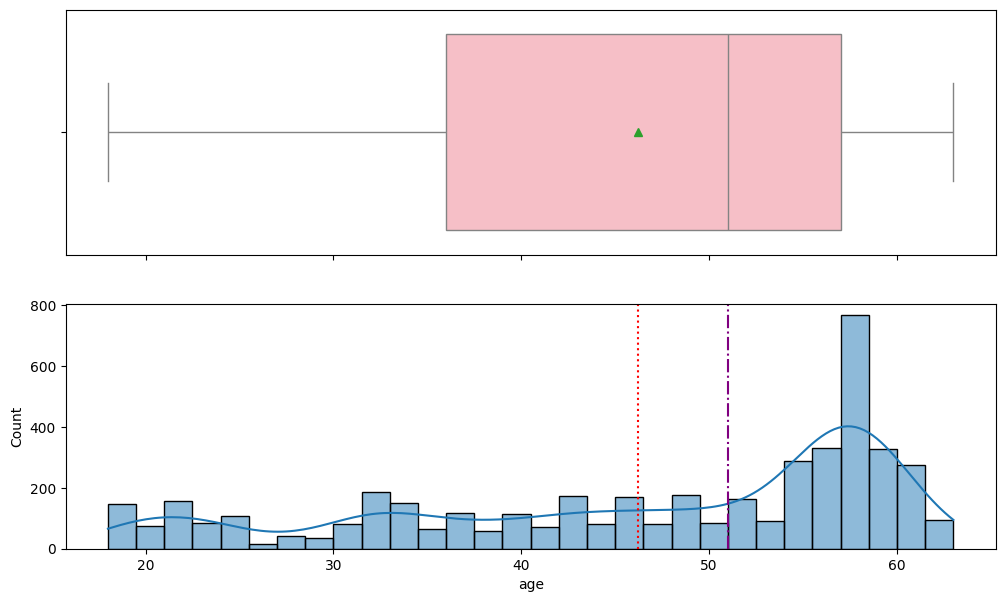

In [16]:
histogram_boxplot(df, "age", kde = True, bins = 30)

## Observations
* The data for age is left skewed, the majority of potential clients are of an older demographic
* The average age in the data is 46 years while the median is 51 years
* This shows older people are more intrested in the courses on offer

### Website Visits

In [17]:
# data description
df['website_visits'].describe()

,website_visits
count,4612.000
mean,3.567
std,2.829
min,0.000
25%,2.000
50%,3.000
75%,5.000
max,30.000


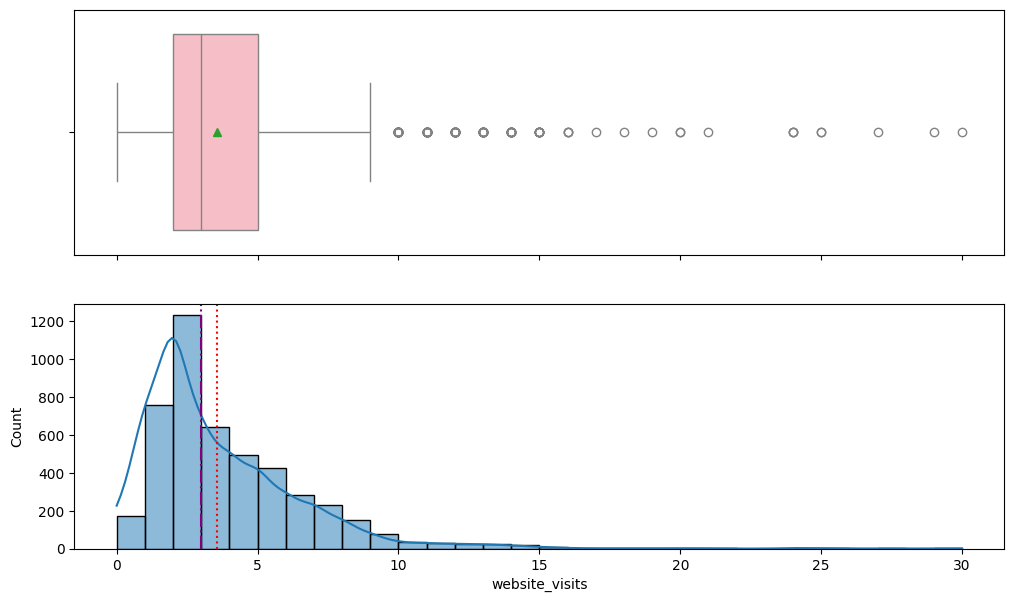

In [18]:
histogram_boxplot(df, "website_visits", kde = True, bins = 30)

## Observations
* The data for website visits is right skewed, as the number of website visits increase the count of visitors reduces
* There is a large number of outliers to the right of the graph
* The potential clients visited the website an average of 3 times

### Time Spent on Website

In [19]:
# data description
df['time_spent_on_website'].describe()

,time_spent_on_website
count,4612.000
mean,724.011
std,743.829
min,0.000
25%,148.750
50%,376.000
75%,1336.750
max,2537.000


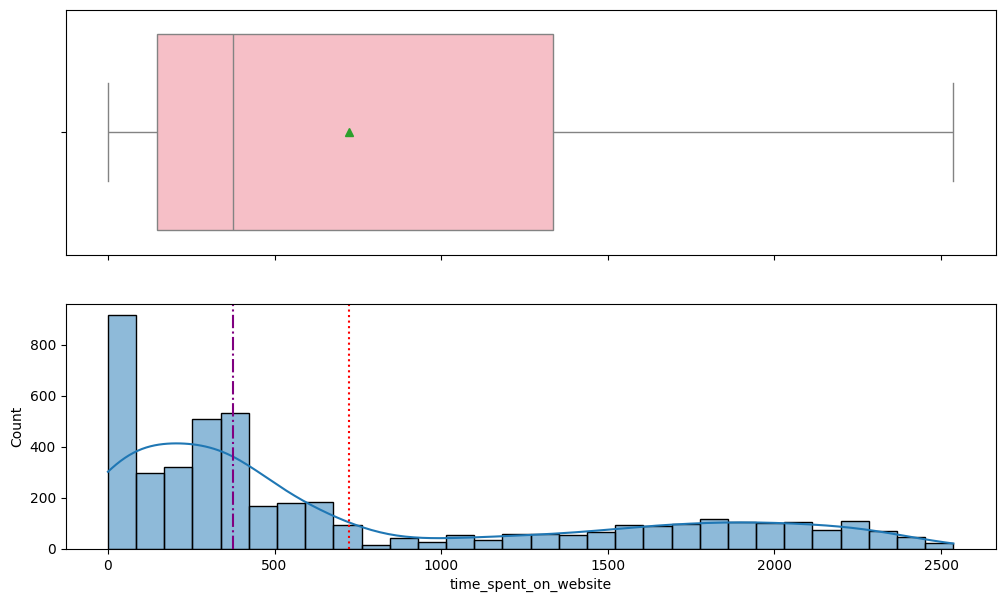

In [20]:
histogram_boxplot(df, "time_spent_on_website", kde = True, bins = 30)

## Observations

* The data for time spent on website is right skewed
* The majority of website visitors spent little time on the website
* The data for time spent on website has a large spread


### Page Views per Visit

In [21]:
# data description
df['page_views_per_visit'].describe()

,page_views_per_visit
count,4612.000
mean,3.026
std,1.968
min,0.000
25%,2.078
50%,2.792
75%,3.756
max,18.434


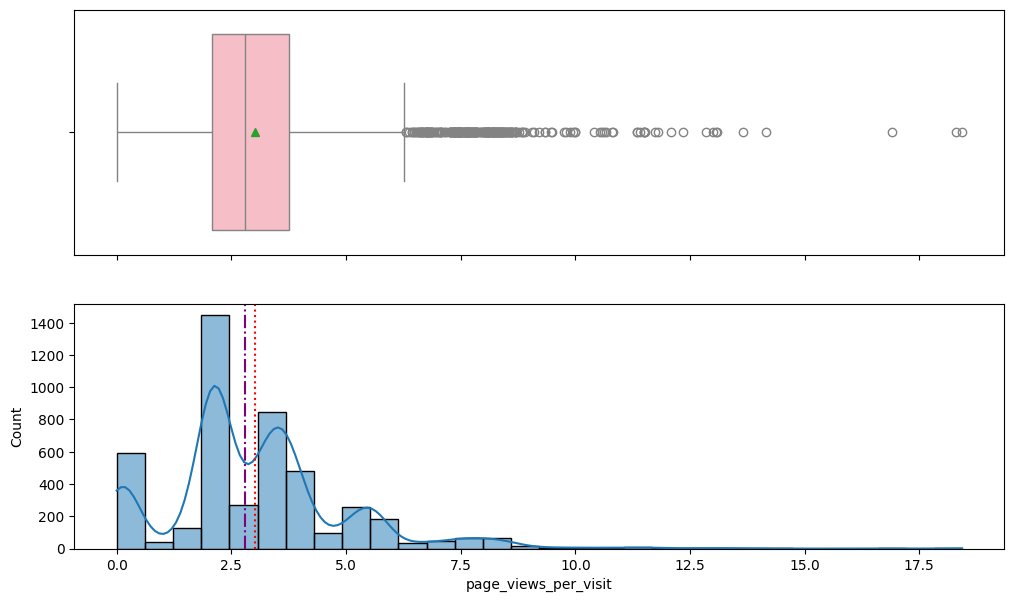

In [22]:
histogram_boxplot(df, "page_views_per_visit", kde = True, bins = 30)

## Observations

* The data for page views per visit is right skewed
* The data has no clearly defined pattern
* On average potential clients viewed 3 pages on the site on each visit

## Bivariate Analysis

### 1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.


In [23]:
# Crosstab for lead by current occupation
current_occupation_lead = pd.crosstab(df["current_occupation"],df["status"],normalize='index')*100
current_occupation_lead

status,0,1
current_occupation,,
Professional,64.488,35.512
Student,88.288,11.712
Unemployed,73.421,26.579


Text(0, 0.5, 'Lead Conversion %')

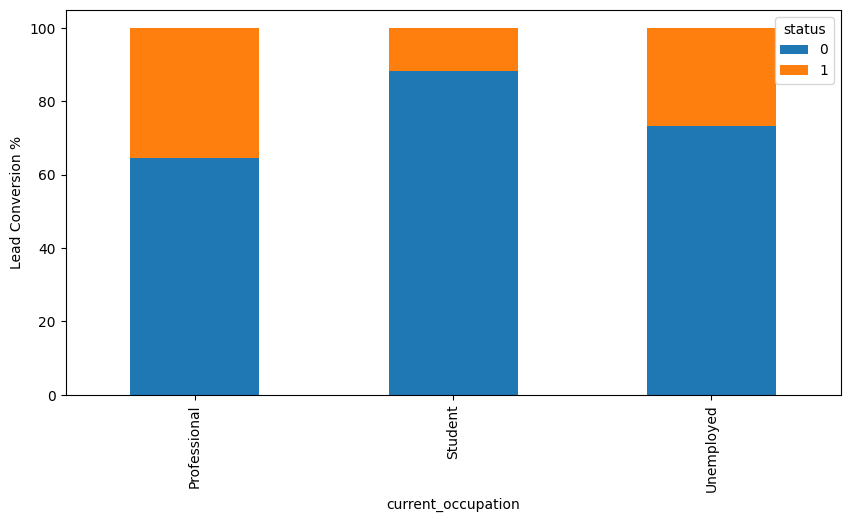

In [24]:
# Stacked bar plot lead conversion by current occupation
current_occupation_lead.plot(kind='bar',figsize=(10,5),stacked=True)
plt.ylabel('Lead Conversion %')

## Observations

* Professionals have the highest rate on conversion at 35%, futhering education may be a way to keep up with job demands, get promoted or switch career path among other reasons.
* Unemployed leads have the second highest conversion rate at 26%, this may be to enable them to break into the job market
* Students have the lowest conversion rate at 11%, this may be due to having a demanding school schedule already

### 2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?


In [25]:
# Crosstab for lead by first interaction
first_interaction_lead = pd.crosstab(df["first_interaction"],df["status"],normalize='index')*100
first_interaction_lead

status,0,1
first_interaction,,
Mobile App,89.469,10.531
Website,54.406,45.594


Text(0, 0.5, 'Lead Conversion %')

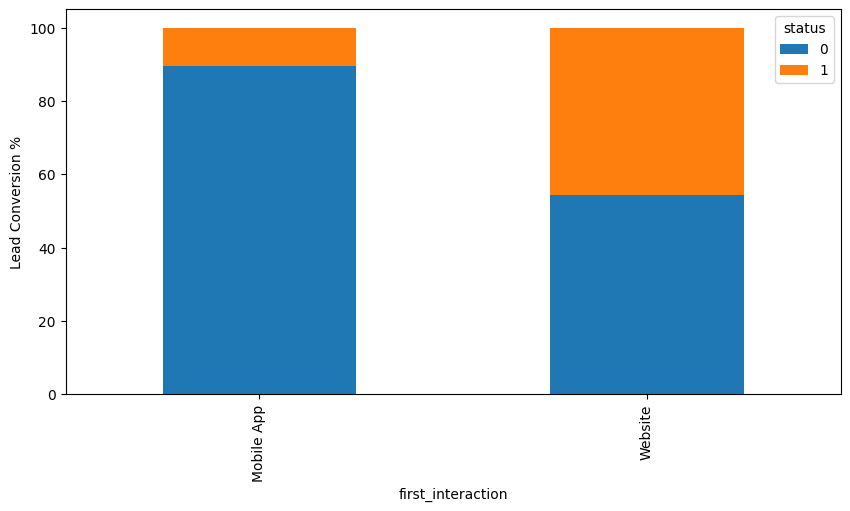

In [26]:
# Stacked bar plot lead conversion by first interaction
first_interaction_lead.plot(kind='bar',figsize=(10,5),stacked=True)
plt.ylabel('Lead Conversion %')

## Observation

* Yes the company's first impression have an impact on the lead
* Those who got their first impression through a website converted at a higher rate than those who got their first impression through mobile
* 45%, alomost half of the potential clients reached through web converted while only 10% converted on mobile

### 3. The company uses multiple modes to interact with prospects. Which way of interaction works best?


In [27]:
# Grouping categorical columns
interaction_mode_columns= ["print_media_type1", "print_media_type2", "digital_media", "educational_channels", "referral"]

# Cross tab of value counts for lead by interation mode
for i in interaction_mode_columns:
    if i!="status":
      print(pd.crosstab(df[i],df["status"]))

status                0     1
print_media_type1            
No                 2897  1218
Yes                 338   159
status                0     1
print_media_type2            
No                 3077  1302
Yes                 158    75
status            0     1
digital_media            
No             2876  1209
Yes             359   168
status                   0     1
educational_channels            
No                    2727  1180
Yes                    508   197
status       0     1
referral            
No        3205  1314
Yes         30    63


## Observations

* Education channels by far reached the most people, so in terms of reach they work best
* Referrals reached the least amount of people by far, so in terms of reach they work least

### 4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?


In [28]:
## Percentages of interaction mode success rate
for i in interaction_mode_columns:
    if i!="status":
      print(pd.crosstab(df[i],df["status"],normalize='index')*100)

status                 0      1
print_media_type1              
No                70.401 29.599
Yes               68.008 31.992
status                 0      1
print_media_type2              
No                70.267 29.733
Yes               67.811 32.189
status             0      1
digital_media              
No            70.404 29.596
Yes           68.121 31.879
status                    0      1
educational_channels              
No                   69.798 30.202
Yes                  72.057 27.943
status        0      1
referral              
No       70.923 29.077
Yes      32.258 67.742


## Observations

* Referrals at 68%, have the highest conversion rate, this may be due to people referring the courses to others whom they think is interested and has a high level of conversion. People also tend to trust referrals from someone they know more than advertising
* Education channels at 28%, have thelowest conversion rate despite reaching the most people

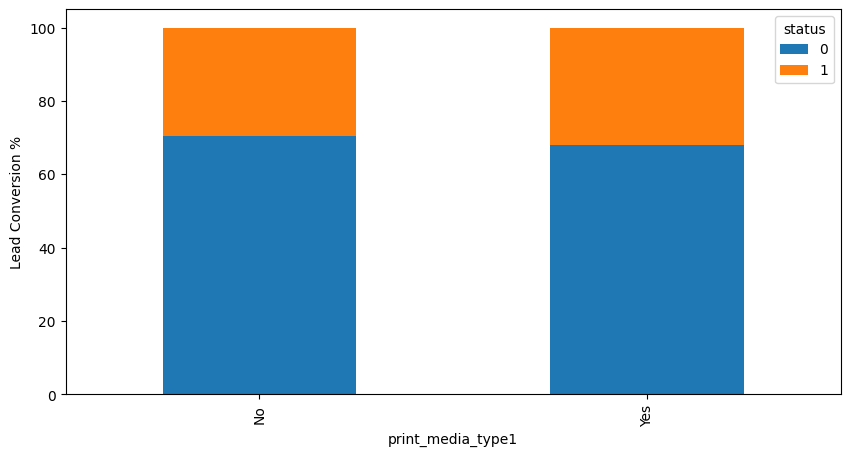

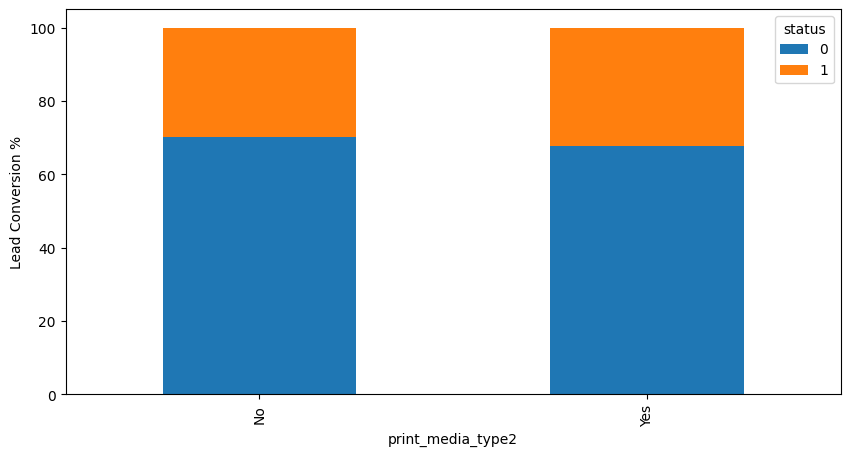

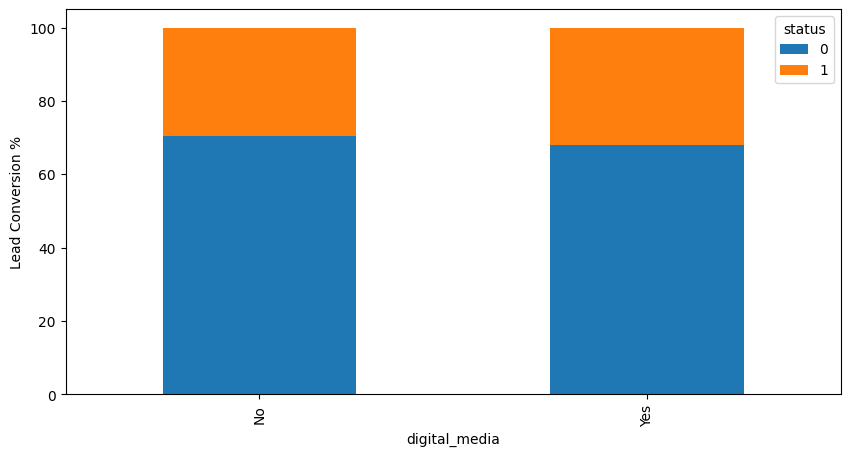

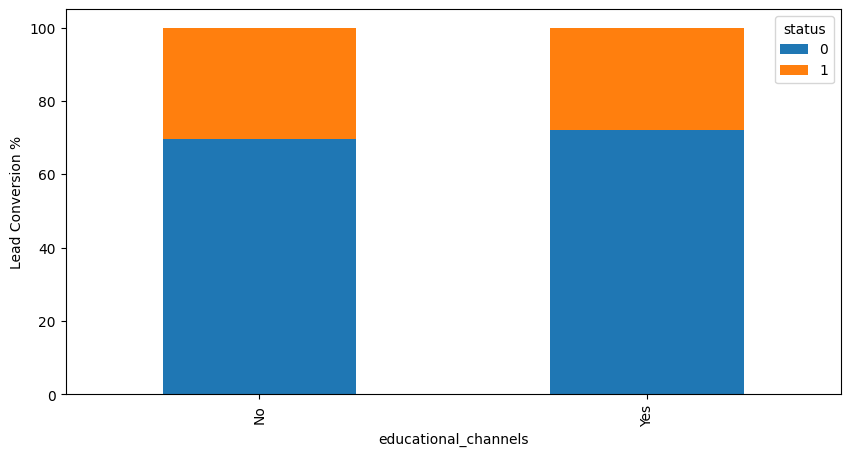

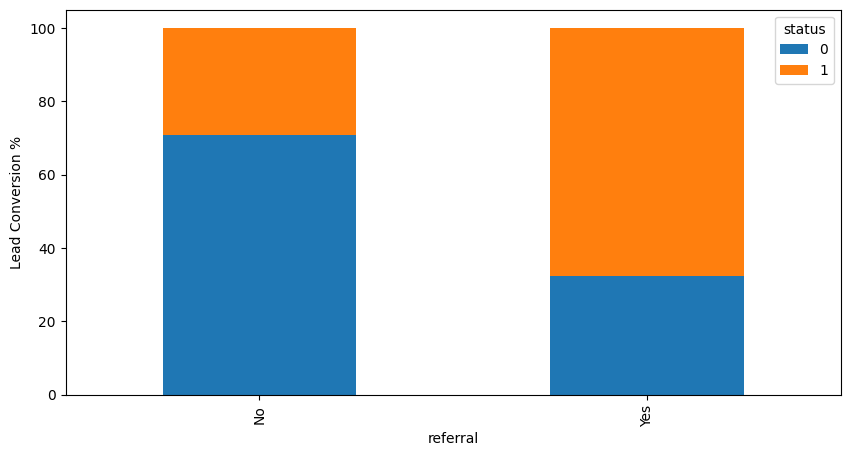

In [29]:
# Stacked bar plot for lead conversion by interaction modes
for i in interaction_mode_columns:
    if i!="status":
        (pd.crosstab(df[i],df["status"],normalize='index')*100).plot(kind='bar',figsize=(10,5),stacked=True)
        plt.ylabel('Lead Conversion %')

### 5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

In [30]:
# Crosstab for lead by profile completion
profile_completion_lead = pd.crosstab(df["profile_completed"],df["status"],normalize='index')*100
profile_completion_lead

status,0,1
profile_completed,,
High,58.216,41.784
Low,92.523,7.477
Medium,81.124,18.876


Text(0, 0.5, 'Lead Conversion %')

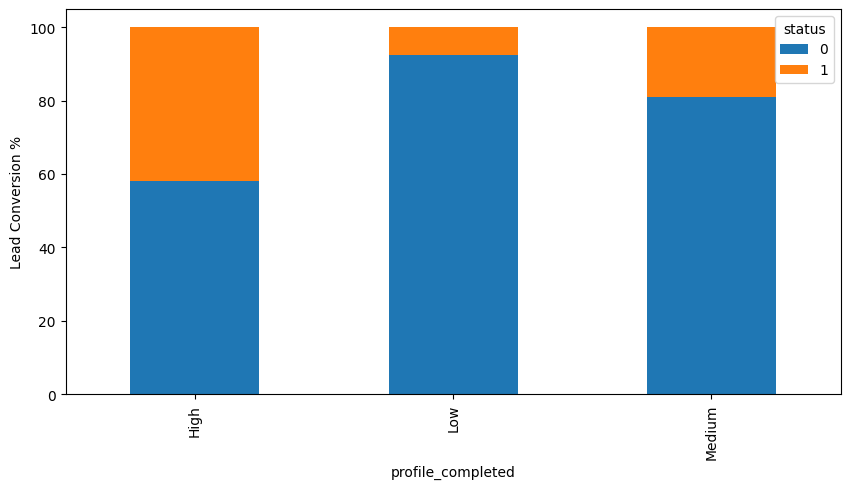

In [31]:
# Stacked bar plot lead conversion by profile completion
(pd.crosstab(df["profile_completed"],df["status"],normalize='index')*100).plot(kind='bar',figsize=(10,5),stacked=True)
plt.ylabel('Lead Conversion %')

## Observations

* Yes, having more details on a profile increases the chances of a lead converting, 42% of the leads with high profile completion converted.
* Leads who have medium profile completion have the second highest conversion rate at 19%
* Leads with the lowest profile completion also have the least chances of converting, the rate just standing at 7%
* This may be due there being more intrest in the courses from leads that complete their profile

### Age of Lead by Conversion Status

Text(0.5, 1.0, 'Age of Lead by Conversion Status')

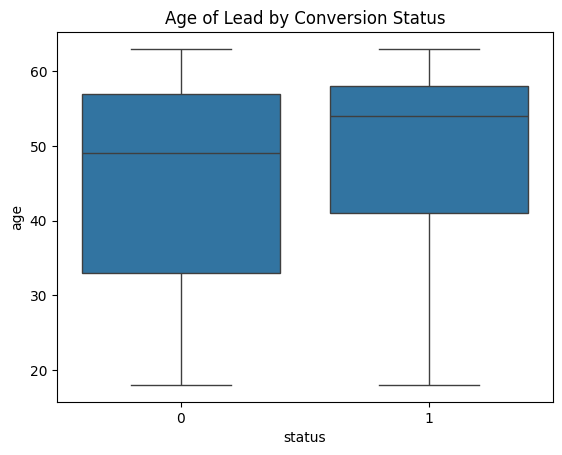

In [32]:
# Categorical box plot to compare age according to lead conversion
sns.boxplot(x = "status", y = "age", data=df, showfliers= False)
# title
plt.title("Age of Lead by Conversion Status")

## Observations

* Older leads have a higher converstion rate on average as shown by the box plots and the medians

### Website Visits by Conversion Status

Text(0.5, 1.0, 'Website Visits by Conversion Status')

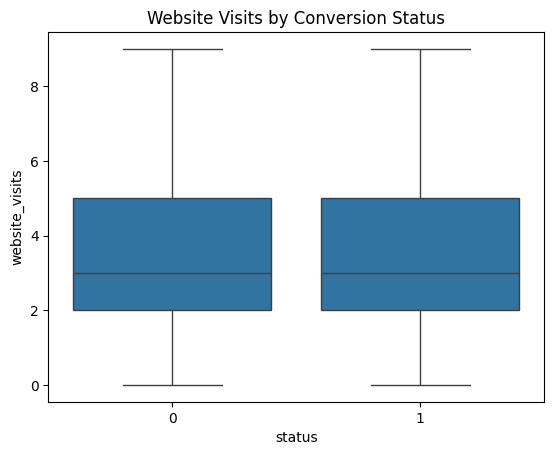

In [33]:
# Categorical box plot to compare website visits according to lead conversion
sns.boxplot(x = "status", y = "website_visits", data=df, showfliers= False)
# title
plt.title("Website Visits by Conversion Status")

## Observations

* Website visits have an equal distribution between those who convert and those who do not
* This attribute can be dropped

### Time Spent on Website by Conversion Status

Text(0.5, 1.0, 'Time Spent on Website by Conversion Status')

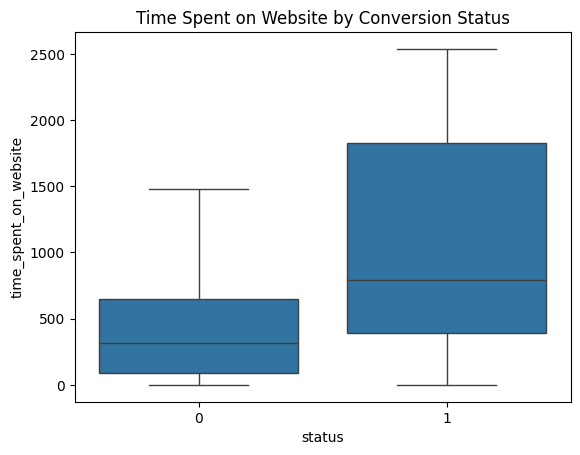

In [34]:
# Categorical box plot to compare time spent on website according to lead conversion
sns.boxplot(x = "status", y = "time_spent_on_website", data=df, showfliers= False)
# title
plt.title("Time Spent on Website by Conversion Status")

## Observations

* Leads that spend a longer time on the website per visit have a higher converstion rate

### Page Views per Visit by Conversion Status

Text(0.5, 1.0, 'Page Views per Visit by Conversion Status')

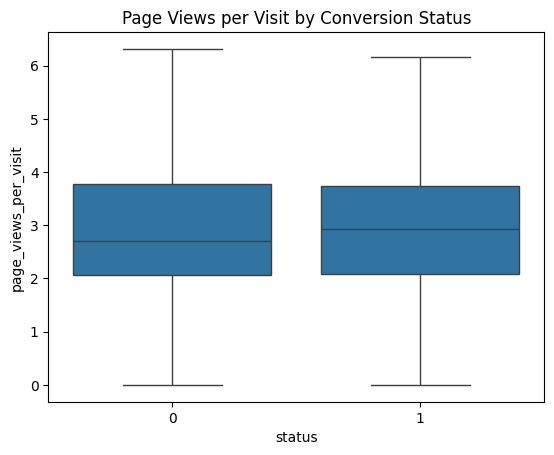

In [35]:
# Categorical box plot to compare page views per visit according to lead conversion
sns.boxplot(x = "status", y = "page_views_per_visit", data=df, showfliers= False)
# title
plt.title("Page Views per Visit by Conversion Status")

## Observations

* Leads that view more pages have a higher rate of conversion as shown by the box plot medians

## Multivariate Analysis

<Axes: >

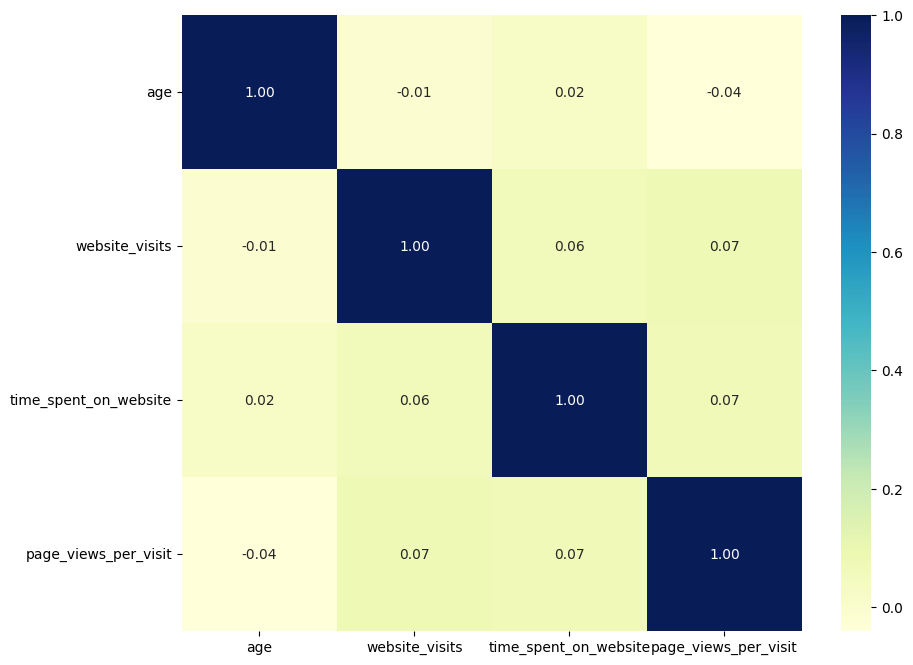

In [36]:
# Plotting the correlation between numerical variables
plt.figure(figsize=(10,8))
sns.heatmap(df[num_columns].corr(),annot=True, fmt='0.2f', cmap='YlGnBu')

## Observation

* There is are no relationships among the numeric variables

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [37]:
# dropping website visits
df = df.drop("website_visits", axis= 1)

### Comment

* The categorical boxplot for website visits showed that there was no significant difference between the leads who converted and the leads who did not.

In [38]:
# Appplying dummy variables to categorical data
df = pd.get_dummies(df, columns = df.select_dtypes(include = ["object", "category"]).columns.tolist(),
    drop_first = True,
)

### Comment

* Encoding our categorical data for machine learning

In [39]:
# Seperating dependant variables from our target variable
x = df.drop("status",axis=1)
y = df["status"]

### Comment

* Dropping status our target variable to seperate it from the rest of the data and then creating a seperate dataframe for the target variable on it's own. These are our x and y values

In [40]:
# Dividing the data into train and test datasets with the test size at 30 percent
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, shuffle = True, random_state = 1)

### Comment

* Splitting our data into train and test sets, the test size being 30 percent

In [41]:
# Checking shape of data
print("x_train", x_train.shape)
print("x_test", x_test.shape)

x_train (3228, 15)
x_test (1384, 15)


## Observations

* The train and test data both have 15 columns


## EDA

- It is a good idea to explore the data once again after manipulating it.

In [42]:
# checking for class inbance in y variable
y.value_counts(normalize=True)

,proportion
status,
0,0.701
1,0.299


Observations

* There is no class inbance in the data because the minority class surpasses 25%
* This will ensure that we do not have more false negatives after training model

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             4612 non-null   int64  
 1   time_spent_on_website           4612 non-null   int64  
 2   page_views_per_visit            4612 non-null   float64
 3   status                          4612 non-null   int64  
 4   current_occupation_Student      4612 non-null   bool   
 5   current_occupation_Unemployed   4612 non-null   bool   
 6   first_interaction_Website       4612 non-null   bool   
 7   profile_completed_Low           4612 non-null   bool   
 8   profile_completed_Medium        4612 non-null   bool   
 9   last_activity_Phone Activity    4612 non-null   bool   
 10  last_activity_Website Activity  4612 non-null   bool   
 11  print_media_type1_Yes           4612 non-null   bool   
 12  print_media_type2_Yes           46

## Observations

* All data has been converted to numeric types
* There are no missing values in the dataframe


In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.000,46.201,13.161,18.000,36.000,51.000,57.000,63.000
time_spent_on_website,4612.000,724.011,743.829,0.000,148.750,376.000,1336.750,2537.000
page_views_per_visit,4612.000,3.026,1.968,0.000,2.078,2.792,3.756,18.434
status,4612.000,0.299,0.458,0.000,0.000,0.000,1.000,1.000


## Observation

* After encoding categorical data now has descriptive statistics

<Axes: >

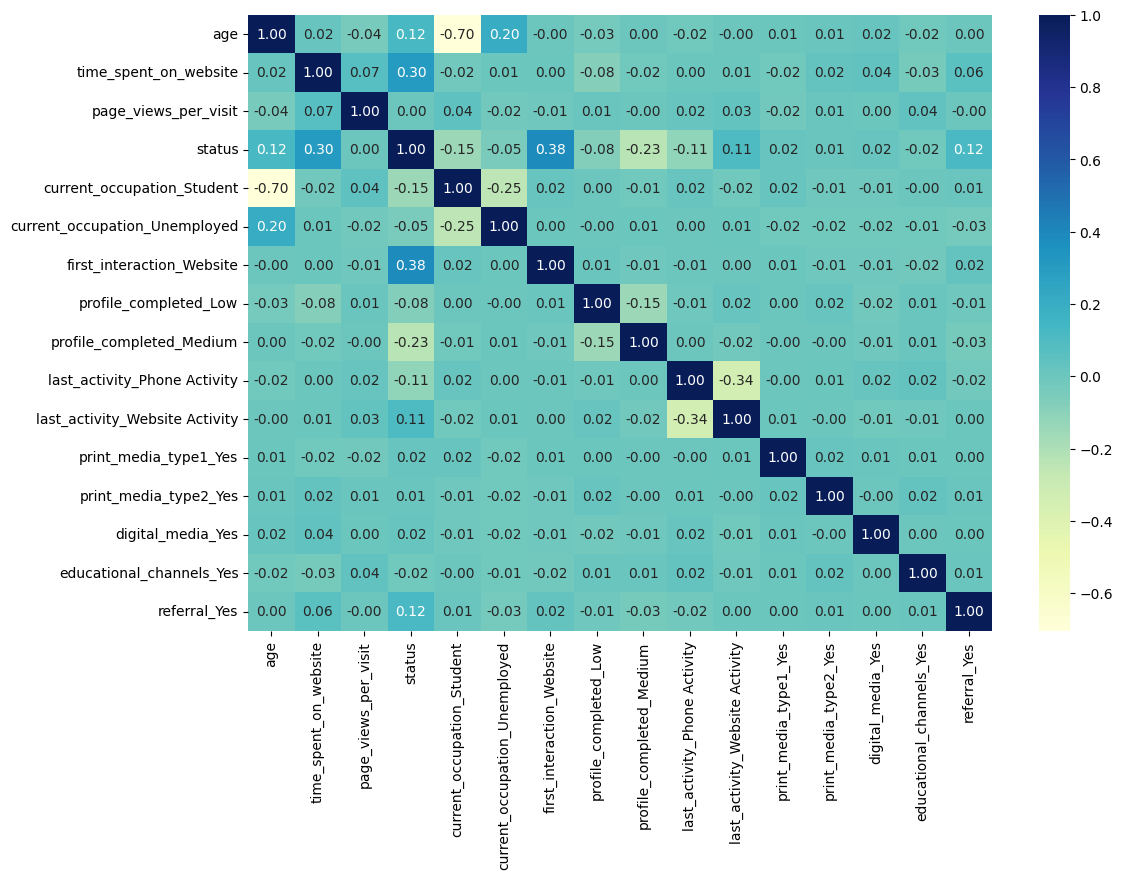

In [45]:
# Plotting the correlation between numerical variables
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True, fmt='0.2f', cmap='YlGnBu')

* Current occupation student and age have a strong negative correlation
* Current occupation age and unemployment have a very weak positive correlation
* Our target variable status is correlated to first interaction website and time spent on website the most



## Building a Decision Tree model

In [46]:
# Creating metric function
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
# heatmap
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Converted', 'Converted'], yticklabels=['Not Converted', 'Converted'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [47]:
# Building decision tree model
dt = DecisionTreeClassifier(random_state = 1)

# Fitting decision tree model
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



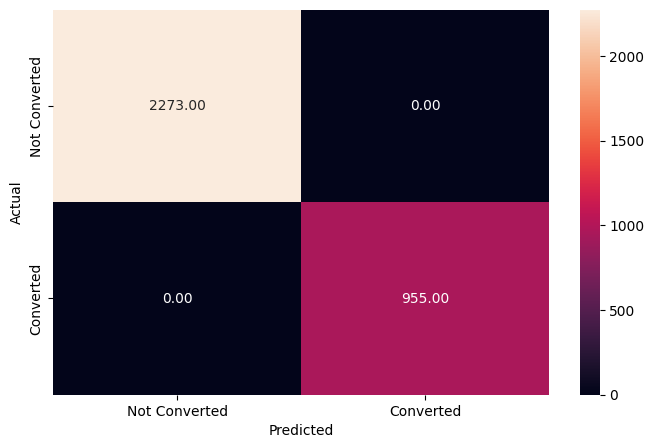

In [48]:
# Checking performance on the training dataset
dt_predictor_y_train = dt.predict(x_train)

metrics_score(y_train, dt_predictor_y_train)

## Observation

* The model has fit the data perfectly, recall on training data is 100%

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       962
           1       0.69      0.69      0.69       422

    accuracy                           0.81      1384
   macro avg       0.78      0.78      0.78      1384
weighted avg       0.81      0.81      0.81      1384



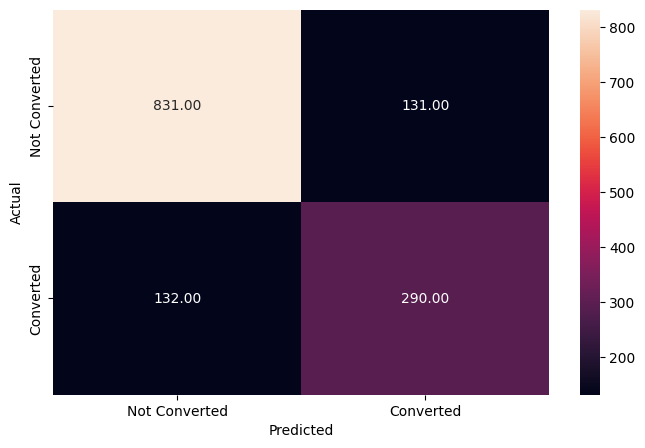

In [49]:
# Checking performance on the test dataset
dt_predictor_y_test = dt.predict(x_test)

metrics_score(y_test, dt_predictor_y_test)

## Observation

* The model perfomed poorly on the test data recall for predicting leads that did not convert is 86% and for predicting those who converted is just 69%
* This is a sign of overfiitng the data
* This model is unusable it will give a lot of false positives for recall predictions

<Axes: xlabel='Importance', ylabel='None'>

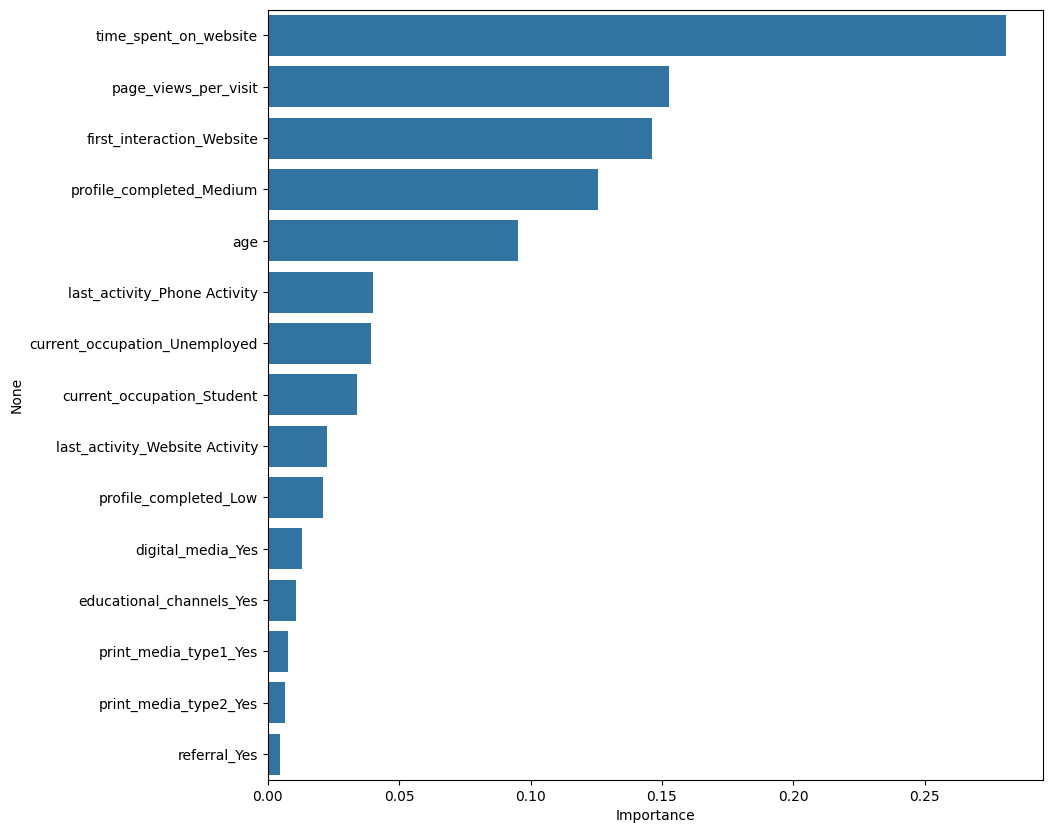

In [50]:
# Plot the feature importance

importances = dt.feature_importances_
columns = x.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (10, 10))
sns.barplot(data = importance_df, x = importance_df.Importance, y = importance_df.index)

## Observations

* All variables seems to be important there is no obvious choice of a variable that needs to be dropped
* Time spent on the website is the most important attribute in this decision tree model
* Referrals are the least important to the model, this may be because they were so few in quantity overall

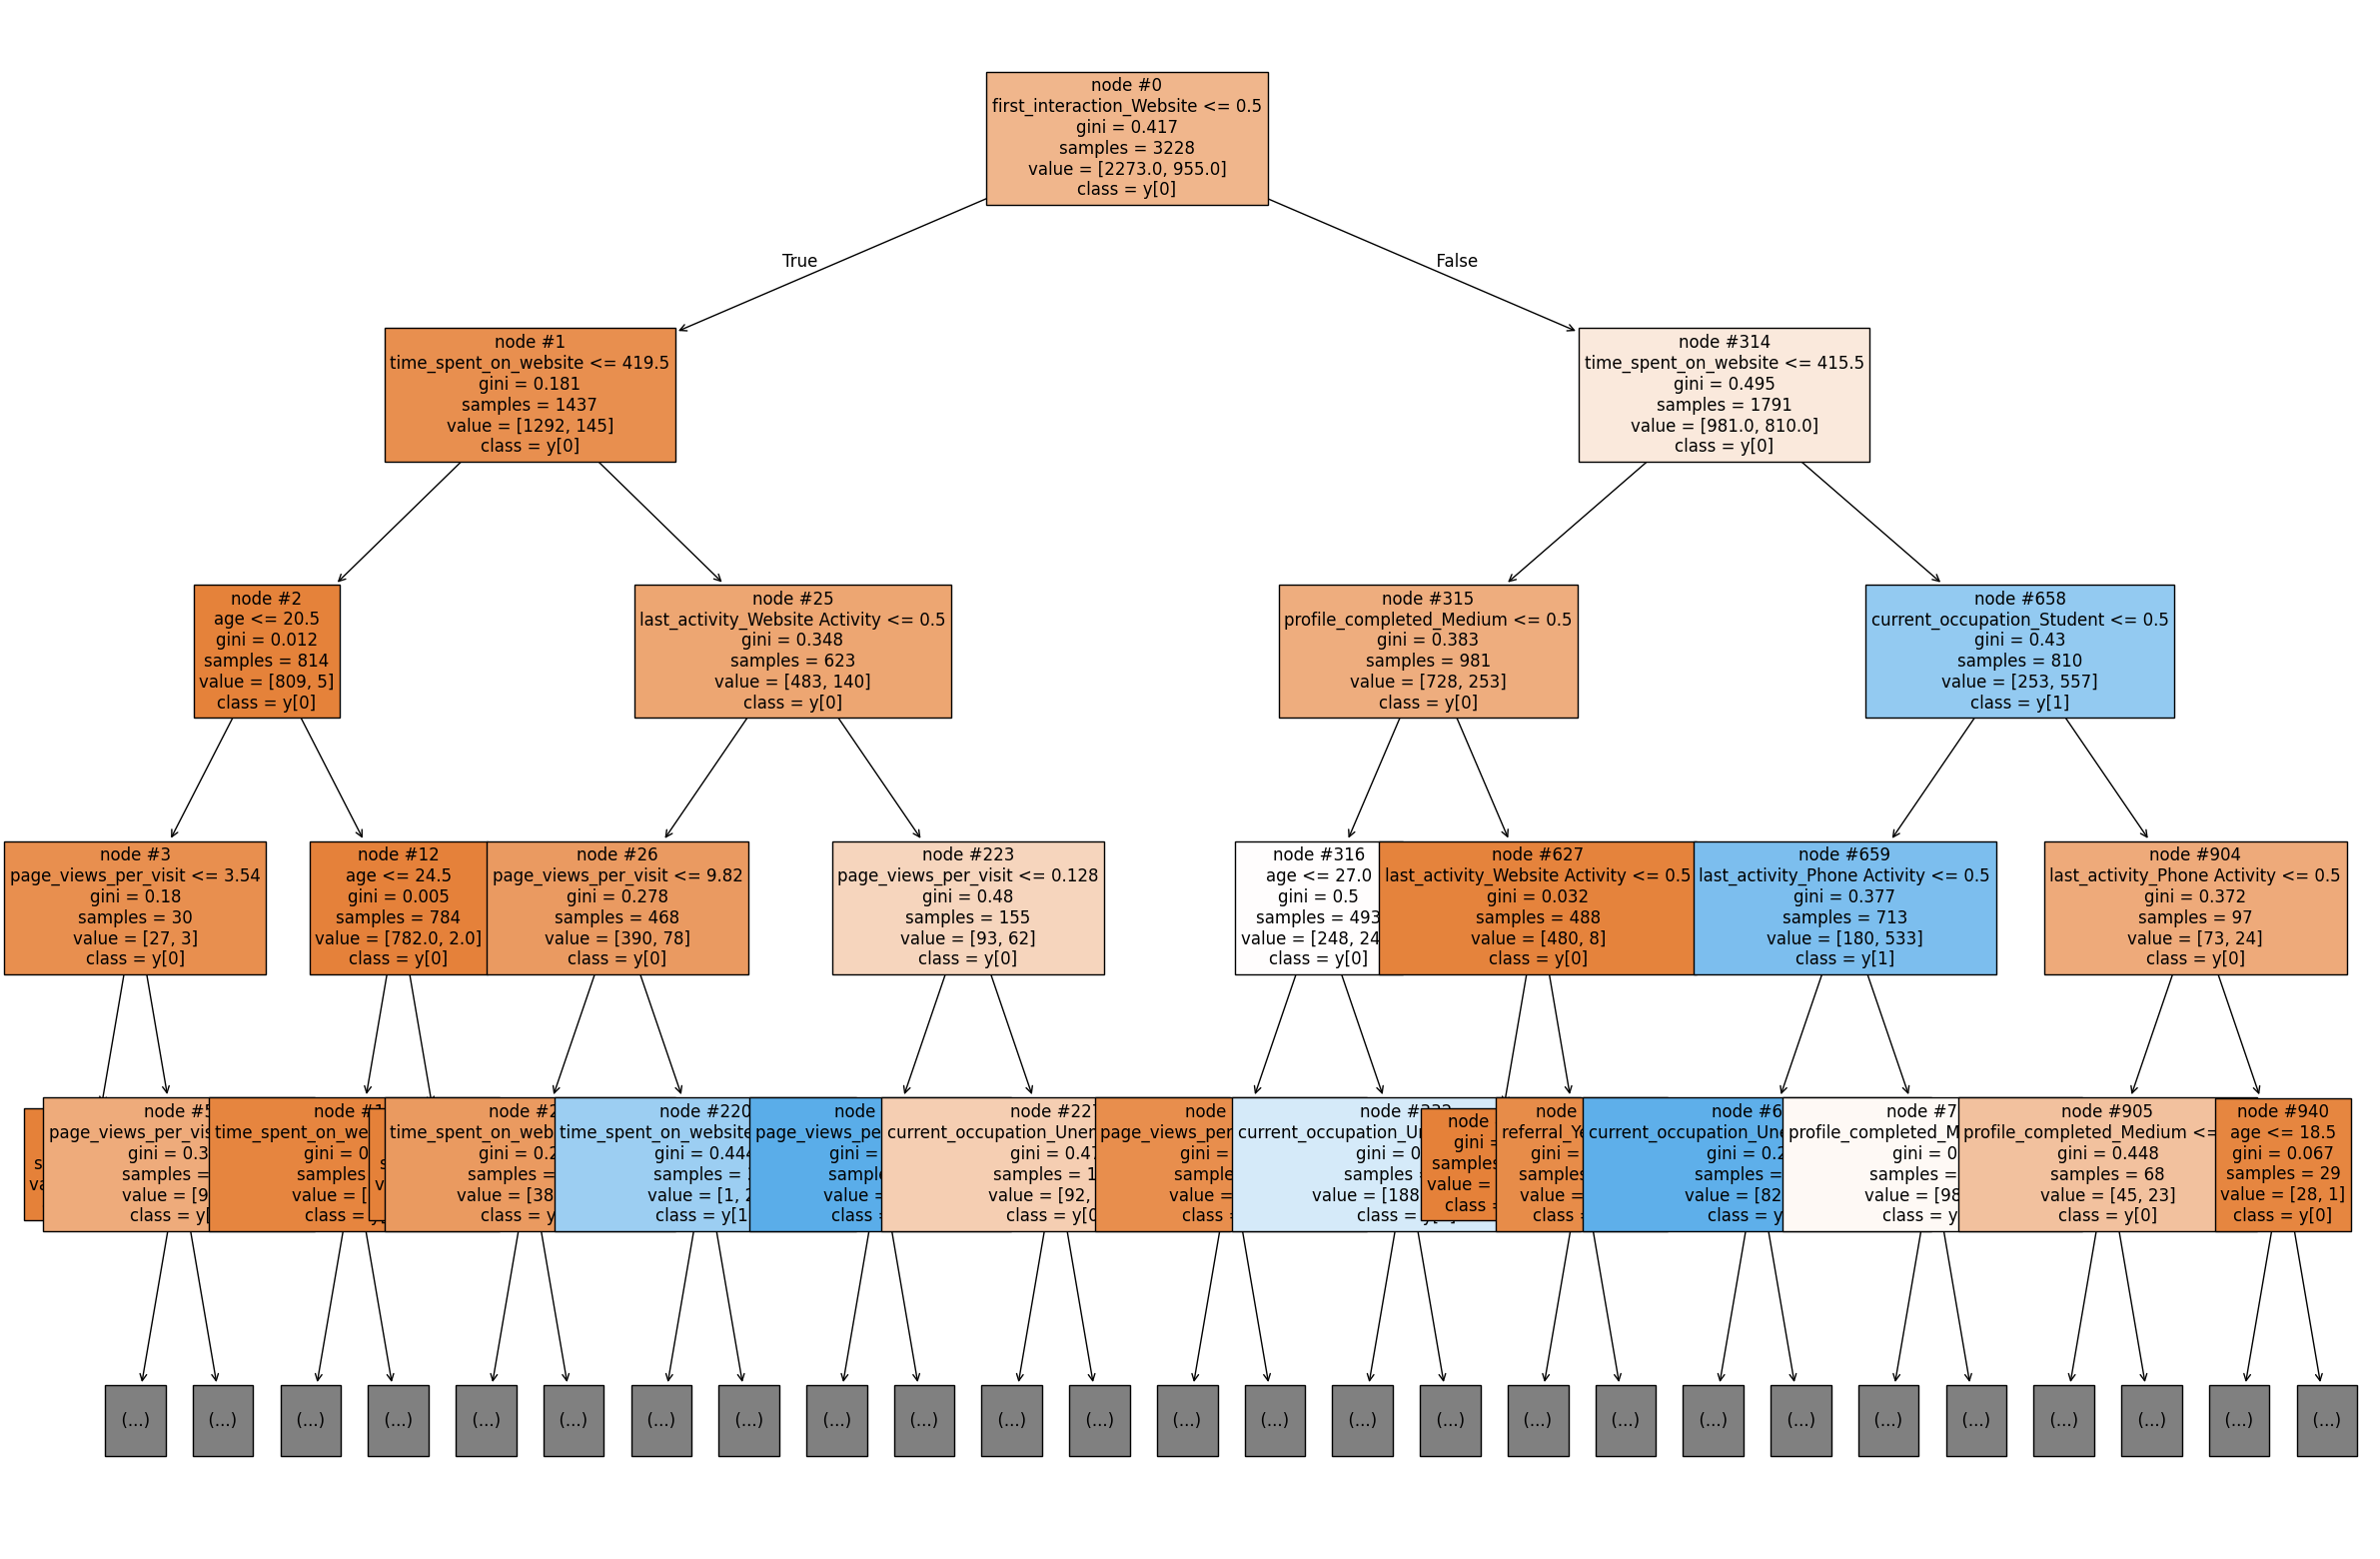

In [51]:
# Visiualizing the decision tree

features = list(x.columns)

plt.figure(figsize = (30, 20))

tree.plot_tree(dt, max_depth = 4, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = True)

plt.show()

### Observation

* First split uses the first interaction attribute
* Time spent on website is used at the second split, an important node that reoccurs throughout the decision tree

## Do we need to prune the tree?

In [52]:
# Choose the type of classifier
dt_estimator = DecisionTreeClassifier(random_state = 1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 8),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
gridCV = GridSearchCV(dt_estimator, parameters, scoring = scorer, cv = 10)

# Fitting the grid search on the train data
gridCV = gridCV.fit(x_train, y_train)

# Set the classifier to the best combination of parameters
dt_estimator = gridCV.best_estimator_

# Fit the best estimator to the data
dt_estimator.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(4),
                       min_samples_leaf=10, random_state=1)

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2273
           1       0.71      0.74      0.72       955

    accuracy                           0.83      3228
   macro avg       0.80      0.81      0.80      3228
weighted avg       0.83      0.83      0.83      3228



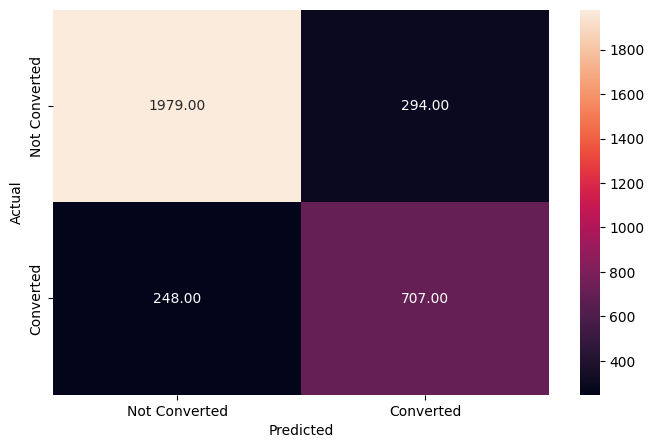

In [53]:
# Checking performance on the training dataset
dt_estimator_y_train = dt_estimator.predict(x_train)

metrics_score(y_train, dt_estimator_y_train)

## Observations

* The training data is underfitting on recall

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       962
           1       0.70      0.73      0.72       422

    accuracy                           0.83      1384
   macro avg       0.79      0.80      0.80      1384
weighted avg       0.83      0.83      0.83      1384



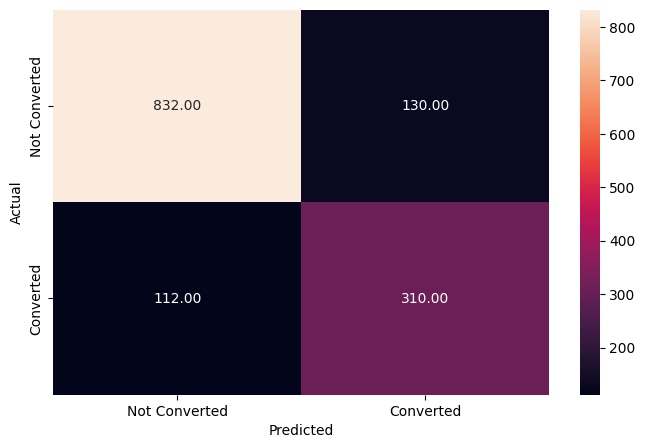

In [54]:
# Checking performance on the test dataset
dt_estimator_y_test = dt_estimator.predict(x_test)

metrics_score(y_test, dt_estimator_y_test)

## Observations

* Yes pruning the model was beneficial
* The test data predictions are consistent with the training data predictions
* Overall accuracy of the model is 83 percent which is an improvement from the original decision tree
* Recall prediction on converted leads is 73 percent accuracy, which is an improvement over the previous model

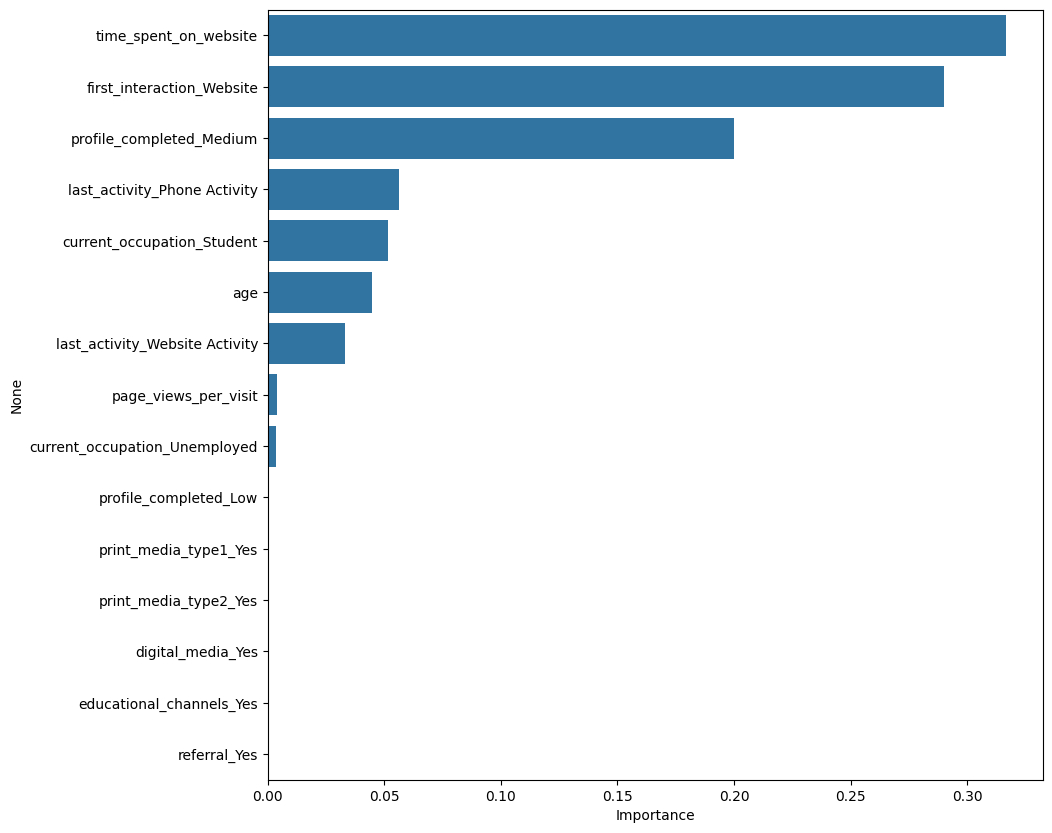

In [55]:
importances = dt_estimator.feature_importances_
columns = x.columns

importance_df = pd.DataFrame(importances, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(data=importance_df, x='Importance', y=importance_df.index)
plt.show()

Observations

* Time spent on website along with first intercaction on website are the most important attributes to this model
* In this model the last 6 attributes can be dropped they are not contributing

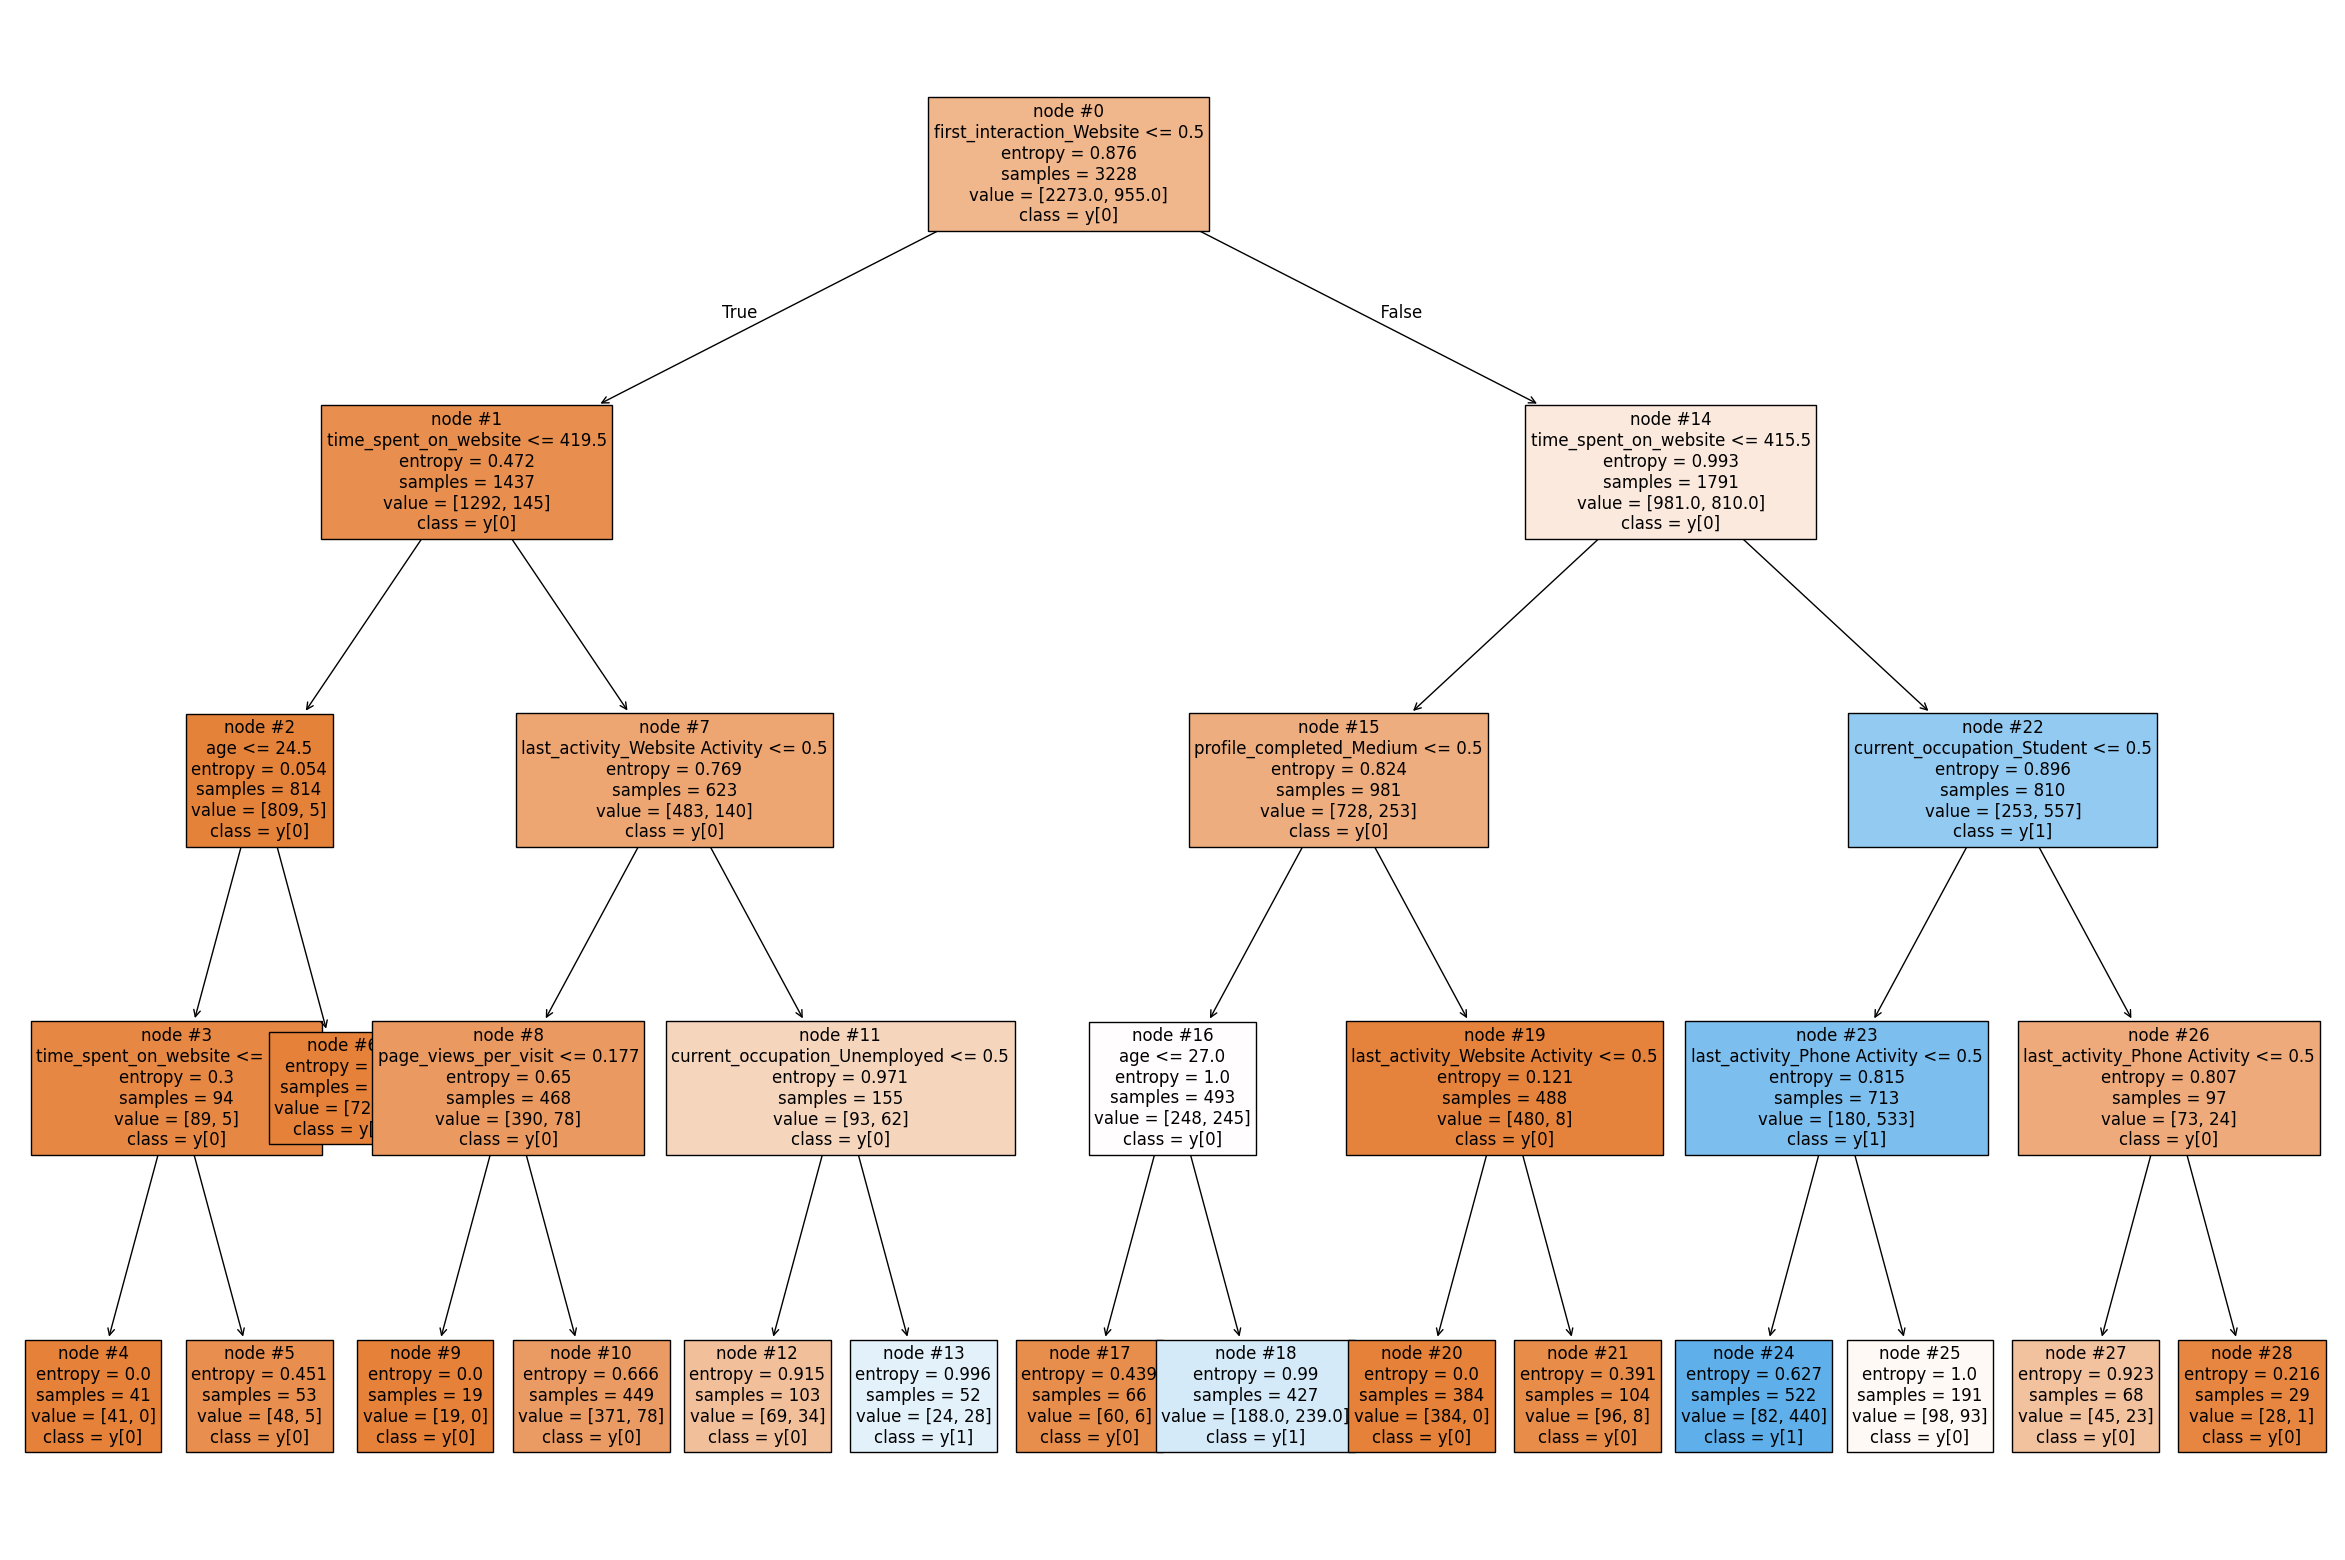

In [56]:
features = list(x.columns)

plt.figure(figsize = (30, 20))

tree.plot_tree(dt_estimator, max_depth = 4, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = True)

plt.show()

## Observations

* The decision tree managed to reduce the entropy to a greater extent

## Building a Random Forest model

In [57]:
# Fitting the Random Forest classifier on the training data
rf_estimator = RandomForestClassifier(random_state = 1)

rf_estimator.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



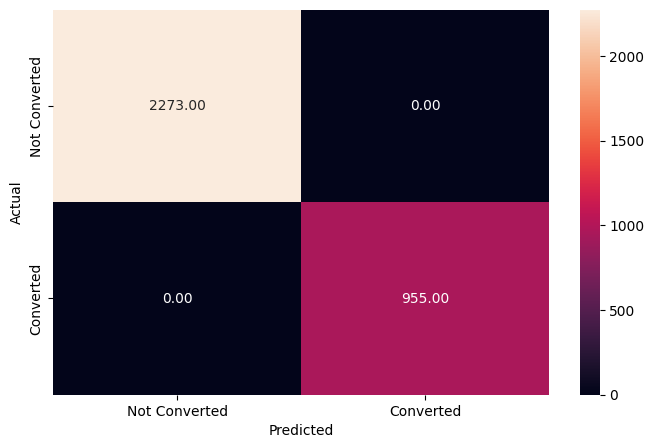

In [58]:
# Checking performance on the training data
rf_estimator_y_train = rf_estimator.predict(x_train)

metrics_score(y_train, rf_estimator_y_train)

## Observation

* The random forest model returned a perfect score on the tranining data

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       962
           1       0.79      0.68      0.73       422

    accuracy                           0.85      1384
   macro avg       0.83      0.80      0.81      1384
weighted avg       0.84      0.85      0.84      1384



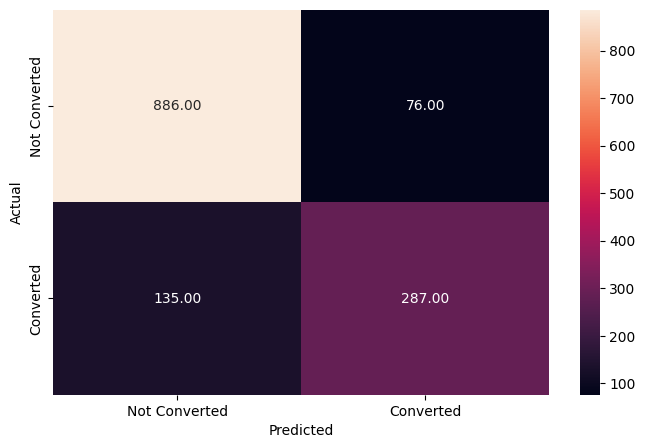

In [59]:
# Checking performance on the testing data
rf_estimator_y_test = rf_estimator.predict(x_test)

metrics_score(y_test, rf_estimator_y_test)

## Observations

* Recall prediction of leads that did not convert perfomed well with 92 percent on the test data
* Recall prediction of leads that converted perfomed poorly with only 68 percent, this may need to be improved
* Overall model accuracy is 85 percent, there is a 15 percent difference with the training model which is a sign of overfitting the data

<Axes: xlabel='Importance', ylabel='None'>

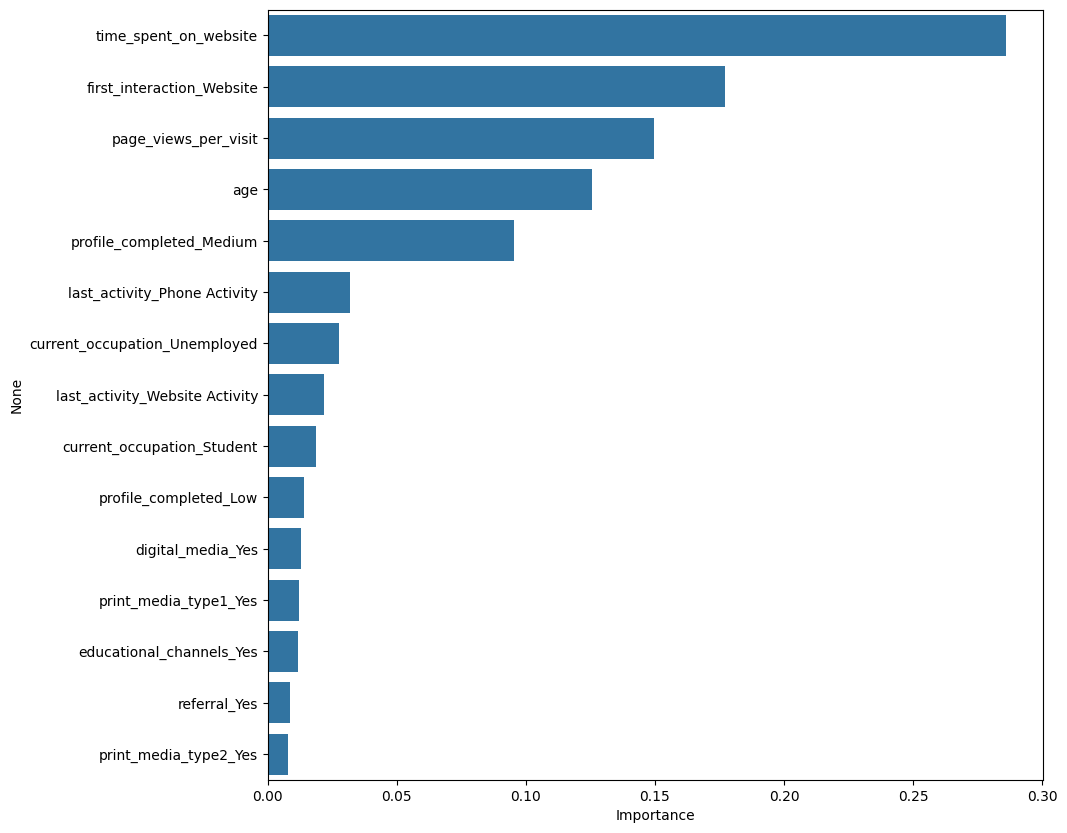

In [60]:
importances = rf_estimator.feature_importances_
columns = x.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (10, 10))
sns.barplot(data = importance_df, x = importance_df.Importance, y = importance_df.index)

## Observations

* Time spent on website and first interaction are still the most important attributes even on this model
* Print media 2 is the least important

## Do we need to prune the tree?

In [61]:
# Choose the type of classifier
tuned_rf_estimator = RandomForestClassifier(random_state = 1)

# Grid of parameters to choose from
params_rf = {
        "n_estimators": [100, 250, 500],
        "min_samples_leaf": np.arange(1, 4, 1),
        "max_features": [0.7, 0.9, 'auto'],
}


# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(tuned_rf_estimator, params_rf, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(x_train, y_train)

# Set the classifier to the best combination of parameters
tuned_rf_estimator = grid_obj.best_estimator_

# Fitting
tuned_rf_estimator.fit(x_train, y_train)

RandomForestClassifier(max_features=0.9, min_samples_leaf=np.int64(3),
                       n_estimators=500, random_state=1)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2273
           1       0.94      0.87      0.90       955

    accuracy                           0.95      3228
   macro avg       0.94      0.92      0.93      3228
weighted avg       0.94      0.95      0.94      3228



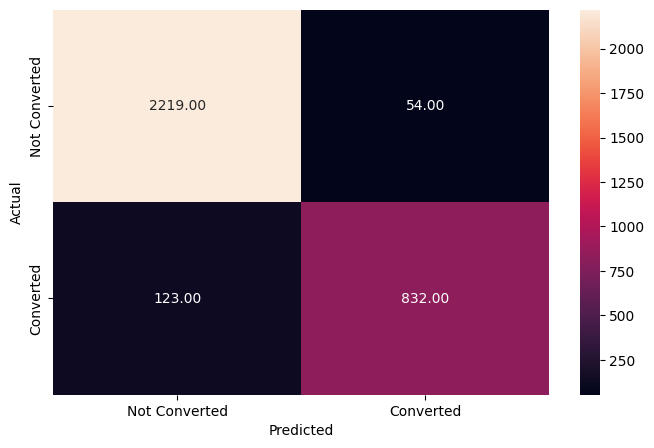

In [62]:
# Checking performance on the training data
tuned_rf_estimator_y_train = tuned_rf_estimator.predict(x_train)

metrics_score(y_train, tuned_rf_estimator_y_train)

## Observations

* The training data recall perfomed well both on converted and not converted leads
* Overall accuracy is 95 percent

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       962
           1       0.81      0.70      0.75       422

    accuracy                           0.86      1384
   macro avg       0.84      0.81      0.83      1384
weighted avg       0.86      0.86      0.86      1384



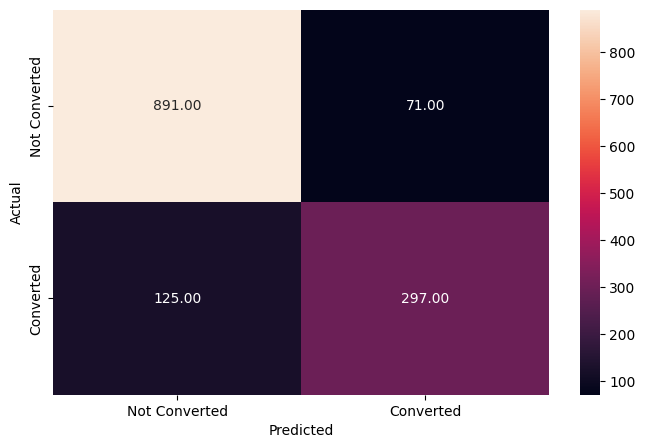

In [63]:
# Checking performance on the testing data
tuned_rf_estimator_y_test = tuned_rf_estimator.predict(x_test)

metrics_score(y_test, tuned_rf_estimator_y_test)

## Observations

* Yes, it was beneficial to tune the random forest model
* Recall prediction for leads that did not convert is 93 percent, a 1 percent improvement over the previous model
* Recall prediction for leads that converted is 70 percent a 2 percent improvement over the previous model
* Overall accuracy is 86 percent 9 percent difference with the traning data model, this may not be the ideal 5 percent difference, but this model is usable and could perfom well on unseen data

<Axes: xlabel='Importance', ylabel='None'>

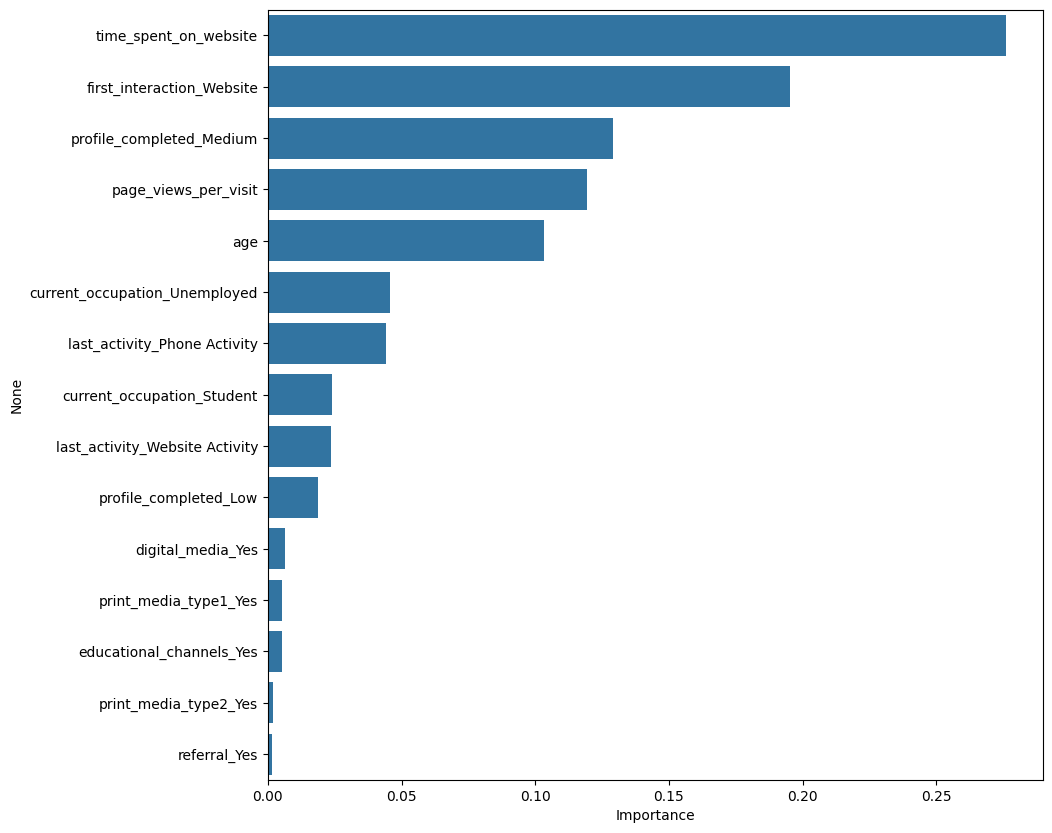

In [64]:
# Plotting feature importance
importances = tuned_rf_estimator.feature_importances_
columns = x.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (10, 10))
sns.barplot(data = importance_df, x = importance_df.Importance, y = importance_df.index)

## Observations

* There are no obvious columns that can be dropped to improve the model
* Time spent on wesite and first interaction are still the most important attributes for the random forest model
* Print media type 2 and referrals are the least important attributes to the model


## Actionable Insights and Recommendations

### Attributes

* On current occupation, Professionals had the highest rate of converting at 35.51 %, this may be due to professionals looking to further their careers or change industries. EdTech should target this category of leads more and focus on personalisation of ads, according to each lead's career interests

* First interaction was the most important element of decision trees and random forest models. Leads who had their first interaction via website converted at a rate of 45.59 % which is much higher than conversion for mobile. EdTech should focus more on website campaigns and adverts to boost the number of leads that have a high chance of converting

* Leads that came through referrals converted at a rate of 67.74 % which is the highest conversion rate among all attributes, however this is also the attribute with the lowest number of leads so its impact was minimal on model building. EdTech should boost the number of leads that come through referral by using an incentiviced promotion, compensating the referers for each converted lead. The promotion could also have milestones for the referers to reach for example reaching 5, 10, 15,...n converted referals should warrant greater compensation.

* On user profiles high completion had the highest rate of conversion at 41.78 %. EdTech should encourage leads to complete their profile through email reminders and also include benefits such as course discounts for completing user profile. This will boost the chances of a lead converting.

* Older demographic in the age attribute converted at a higher rate than those who were younger. This may be because the courses attract leads who already have some sort of tetiary education and are looking to further their careers.
EdTech should make thier courses more attractive to younger leads by outlining in their campaings how their courses help clients get a job or break into different industries

* Time spent on website was the second most influencial attribute on model buiding. The longer a lead spent on the website, the more likely they were to convert, this indicates that leads who stay longer on the site are more invested in the courses on offer. EdTech should follow up on leads that spent more time on the website but did not convert to find out what the issue was and if it can be resolved.

### Machine Learning Models

* Prunned Decision Tree and Tuned Random Forest Model were the two most succesful models

* Prunned Decision Tree had an overall accuracy of 83 %. Recall prediction using test data, the model had an accuracy of 73 % on converted leads and 86 % on unconverted leads.

* Tuned Random Forest Model had an overall accuracy of 86 %. Recall prediction using test data, the model had an accuracy of 70 % on converted leads and 93 % on unconverted leads.

* Both models perfomed better on predicting leads that would not convert than predicting leads that did convert, this is because only 30 % of the data is of leads that converted. To improve the models more data would be needed overall for the training models to have more information to work with.

* The better choice between the two models is the Tuned Random Forest, for this particular task of increasing lead conversion, 70 % recall prediction accompanied by 86% overall accuracy is good.

* EdTech should use the Tuned Random Forest model to identify leads who are more likely to convert.